In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(project_root)

c:\Users\Aditi Mundra\OneDrive\Desktop\Butterfly Classification


In [2]:
from tensorflow.keras.models import load_model

from src.evaluate import (
    get_predictions,
    get_true_labels,
    generate_classification_report,
    generate_confusion_matrix
)

from src.visualization import (
    plot_confusion_matrix
)

In [3]:
model = load_model(
    "../outputs/models/best_model.keras"
)

In [4]:
from src.dataset import prepare_dataset

In [5]:
(
    X_train,
    X_test,
    y_train,
    y_test,
    labels,
    encoder
) = prepare_dataset()

In [6]:
print(X_test.shape)
print(y_test.shape)

(167, 224, 224, 3)
(167, 10)


In [7]:
y_pred = get_predictions(
    model,
    X_test
)

y_true = get_true_labels(
    y_test
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 43s 7s/step


In [8]:
print(
    generate_classification_report(
        y_true,
        y_pred,
        sorted(set(labels))
    )
)

              precision    recall  f1-score   support

         001       1.00      1.00      1.00        16
         002       1.00      1.00      1.00        19
         003       1.00      1.00      1.00        12
         004       1.00      1.00      1.00        18
         005       1.00      1.00      1.00        18
         006       1.00      1.00      1.00        20
         007       1.00      0.94      0.97        18
         008       1.00      1.00      1.00        11
         009       1.00      1.00      1.00        18
         010       0.94      1.00      0.97        17

    accuracy                           0.99       167
   macro avg       0.99      0.99      0.99       167
weighted avg       0.99      0.99      0.99       167



In [9]:
cm = generate_confusion_matrix(
    y_true,
    y_pred
)

C:\Users\Aditi Mundra\AppData\Local\Temp\ipykernel_13032\4281475023.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


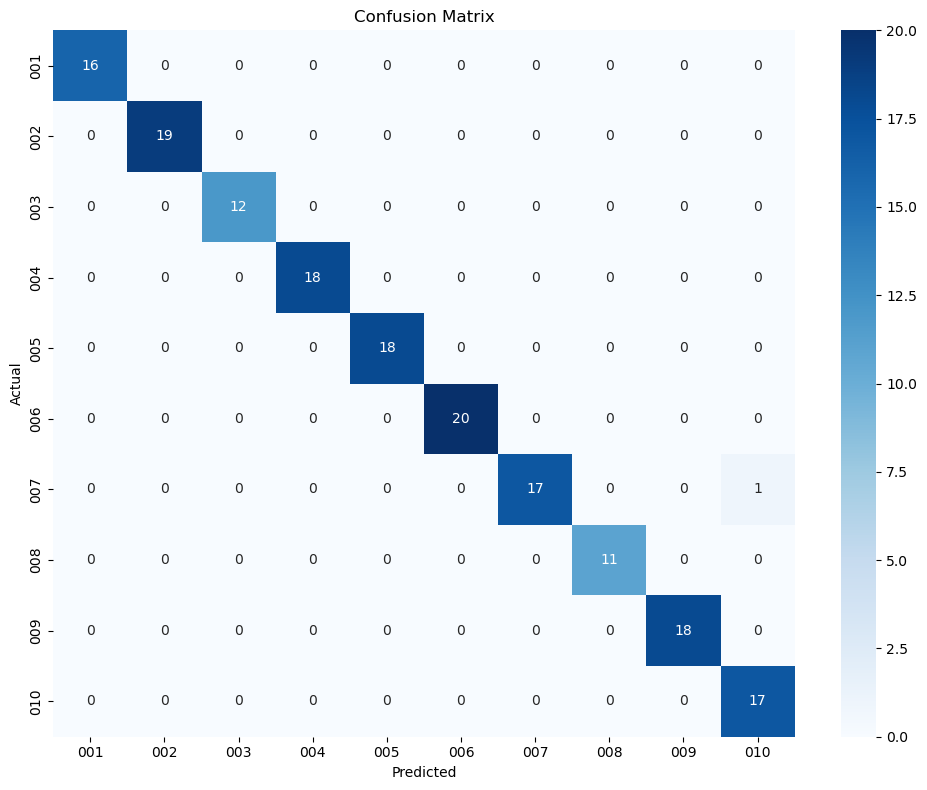

In [10]:
fig = plot_confusion_matrix(cm,sorted(set(labels)))

fig.savefig(
    "../outputs/figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

fig.show()